In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns;

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df=sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
df.shape

(891, 15)

In [6]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df.drop(columns=['class','who','adult_male','deck','alive','alone','embarked'], inplace=True)

In [9]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,Southampton
887,1,1,female,19.0,0,0,30.0000,Southampton
888,0,3,female,NaN,1,2,23.4500,Southampton
889,1,1,male,26.0,0,0,30.0000,Cherbourg


In [10]:
mode_embark=df["embark_town"].mode()[0]

In [11]:
df["embark_town"]=df["embark_town"].fillna(mode_embark)
df["embark_town"]

,embark_town
0,Southampton
1,Cherbourg
2,Southampton
3,Southampton
4,Southampton
...,...
886,Southampton
887,Southampton
888,Southampton
889,Cherbourg


In [12]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embark_town,0


<Axes: ylabel='age'>

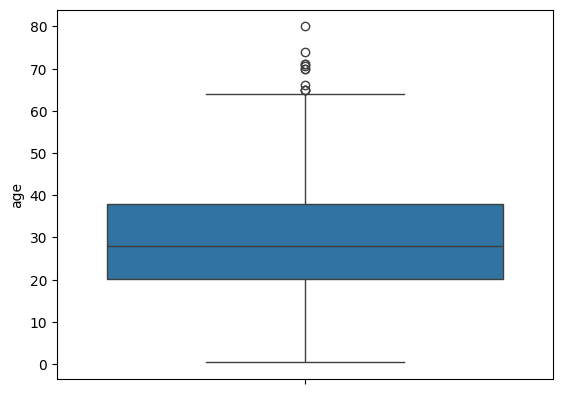

In [13]:
sns.boxplot(df['age'])

In [14]:
median_val=df["age"].median()
median_val

28.0

In [15]:
df["age"]=df["age"].fillna(median_val)

In [16]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embark_town,0


In [17]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
q1=df.describe()["age"]["25%"]
q1

np.float64(22.0)

In [19]:
q3=df.describe()["age"]["75%"]
q3

np.float64(35.0)

In [20]:
IQR=q3-q1
IQR

np.float64(13.0)

In [21]:
lower_limit=q1-1.5*IQR
lower_limit

np.float64(2.5)

In [22]:
upper_limit=q3+1.5*IQR
upper_limit

np.float64(54.5)

In [23]:
df["age"]=df["age"].clip(lower_limit,upper_limit)

<Axes: ylabel='age'>

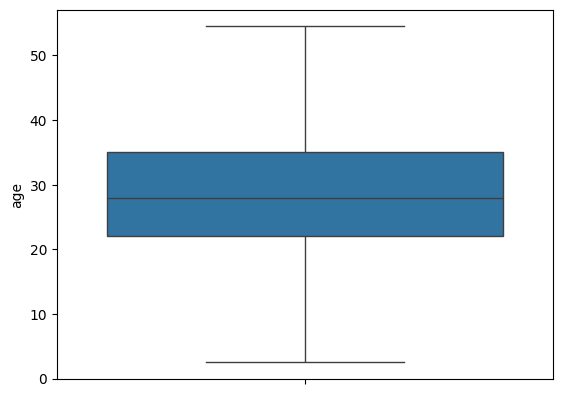

In [24]:
sns.boxplot(df['age'])

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton


In [26]:
df = pd.get_dummies(df, columns=["embark_town", "sex"], drop_first=True, dtype="int64")

In [27]:
df

,survived,pclass,age,sibsp,parch,fare,embark_town_Queenstown,embark_town_Southampton,sex_male
0,0,3,22.0,1,0,7.2500,0,1,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,1,0
3,1,1,35.0,1,0,53.1000,0,1,0
4,0,3,35.0,0,0,8.0500,0,1,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,0,1,1
887,1,1,19.0,0,0,30.0000,0,1,0
888,0,3,28.0,1,2,23.4500,0,1,0
889,1,1,26.0,0,0,30.0000,0,0,1


Decision trees don't need teature scaling because they onry ask questions like "is this value greater than or less than a certain number they dont calculate distances between data points, so the size or scale of the number dont matter

In [28]:
x=df.drop (columns="survived")
x.head()

,pclass,age,sibsp,parch,fare,embark_town_Queenstown,embark_town_Southampton,sex_male
0,3,22.0,1,0,7.2500,0,1,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,1,0
3,1,35.0,1,0,53.1000,0,1,0
4,3,35.0,0,0,8.0500,0,1,1


In [29]:
y=df["survived"]
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=43)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model=DecisionTreeClassifier()

In [32]:
dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

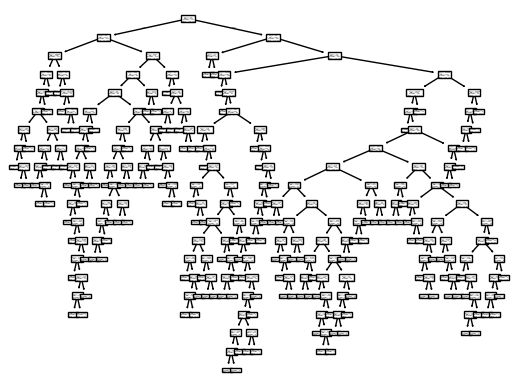

In [33]:
plot_tree(dt_model)
plt.show()

In [34]:
y_pred=dt_model.predict(x_test)

In [35]:
confusion_matrix(y_pred,y_test)

array([[93, 29],
       [17, 40]])

In [36]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


In [37]:
from sklearn.metrics import accuracy_score,precision_score

In [38]:
accuracy_score(y_pred,y_test)

0.7430167597765364

In [39]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(max_iter=1000)
model1.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred1=model1.predict(x_test)

In [41]:
accuracy_score(y_pred1,y_test)

0.7374301675977654

In [42]:
df.head(2)

,survived,pclass,age,sibsp,parch,fare,embark_town_Queenstown,embark_town_Southampton,sex_male
0,0,3,22.0,1,0,7.2500,0,1,1
1,1,1,38.0,1,0,71.2833,0,0,0


In [43]:
def passenger_survival_predictor(  pclass ,age  ,sibsp, parch,  fare, embark_town_Queenstown, embark_town_Southampton,  sex_male ):

  result = dt_model.predict( [[pclass ,age  ,sibsp, parch,  fare, embark_town_Queenstown, embark_town_Southampton,  sex_male]] )

  return "survived" if result == 1 else "not survived"

In [44]:
passenger_survival_predictor( 3,22,1,0,7.25,0,1,1 )

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


'not survived'

# Gradio

In [45]:
%%capture
pip install gradio

In [46]:
import gradio as gr

In [ ]:
import gradio as gr
import numpy as np

def predict_survival(pclass, sex, age, fare):
    try:
        # Convert inputs to float
        features = np.array([[float(pclass), float(sex), float(age), float(fare)]])

        # Predict
        prediction = dt_model.predict(features)

        # Return as integer
        return int(prediction[0])

    except Exception as e:
        return f"Error: {e}"

demo = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Number(label="Pclass"),
        gr.Number(label="Sex (0=Male, 1=Female)"),
        gr.Number(label="Age"),
        gr.Number(label="Fare")
    ],
    outputs=gr.Textbox(label="Prediction")
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5e61f17dab0390dcf1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
